In [17]:
from datetime import datetime
import pandas as pd
import networkx as nx
from visualize_ean import plot_ean, draw_ean
from build_ean import build_ean, add_headway_arcs, propagate, enrich_trip_data_with_boundaries, propagate2
import headway_integration as hi
import numpy as np
from collections import defaultdict
import sys
from pathlib import Path as path

project_root = path(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\AusbauVinschgau")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from tools.schematic_map.routing import (build_route,get_signal_nodes_on_route,)
from infra_data.scenarios import load_network_csv, load_headways


# Import infrastructure and timetable, clean and prepare data

In [18]:
def reassign_trip_ids_by_departure(trip_data, first_station="ME", second_station="MAL", save_path=None):
    entries_first = []
    entries_second = []
    entries_other = []

    for old_id, stops in trip_data.items():
        if not stops:
            continue
        first_stop = stops[0][0]
        # prefer explicit departure time at index 2, fallback to index 1
        dep_time = None
        if len(stops[0]) > 2 and stops[0][2] is not None:
            dep_time = stops[0][2]
        elif len(stops[0]) > 1:
            dep_time = stops[0][1]
        else:
            dep_time = pd.NaT

        record = (old_id, dep_time)
        if first_stop == first_station:
            entries_first.append(record)
        elif first_stop == second_station:
            entries_second.append(record)
        else:
            entries_other.append(record)

    # sort by departure time (NaT will go last)
    def _sort_key(x): return (pd.Timestamp.max if pd.isna(x[1]) else x[1])
    entries_first.sort(key=_sort_key)
    entries_second.sort(key=_sort_key)
    entries_other.sort(key=_sort_key)

    ordered_old_ids = [r[0] for r in (entries_first + entries_second + entries_other)]

    new_trip_data = {}
    for new_id, old_id in enumerate(ordered_old_ids, start=1):
        new_trip_data[new_id] = trip_data[old_id]

    if save_path:
        np.save(save_path, new_trip_data, allow_pickle=True)

    return new_trip_data, ordered_old_ids

# Example usage:
# new_trip_data, ordered_old_ids = reassign_trip_ids_by_departure(trip_data, "ME", "MAL", save_path="inputs2/trip_data_reassigned.npy")
# selected_trips_sorted = np.array(list(new_trip_data.keys()))

In [19]:
nodesDf = load_network_csv("nodes.csv", "node_id")
edgesDf = load_network_csv("edges.csv", "edge_id")
#edgesDf["length"] = (edgesDf["node_to"].map(nodesDf["pk_rel"])- edgesDf["node_from"].map(nodesDf["pk_rel"])).abs()
#trip_data = np.load(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\plottingRailML\230215 FBS Fpl 2026-NB-1443983-3.npy", allow_pickle=True).item()
trip_data = np.load(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\plottingRailML\RidottoStamm6.npy", allow_pickle=True).item()
#trip_data = np.load(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\SimulatedAnnealing\MinimumHeadways\retry\data\trip_data_17.npy", allow_pickle=True).item()
headway_dict = load_headways()
selected_trips_sorted = np.array(list(trip_data.keys()))

In [20]:
trip_data = {
    train_id: [
        (station, arr_dt, dep_dt, True)
        for station, arr_dt, dep_dt in stops
    ]
    for train_id, stops in trip_data.items()
}

In [21]:
trip_data, ordered_old_ids=reassign_trip_ids_by_departure(trip_data)

In [22]:
routing_results = {}

for stop_col in ["stop_slow", "stop_fast"]:

    stops = nodesDf.index[(nodesDf[stop_col] == 1) & (nodesDf["y"] == 0)].tolist()

    for start, end in zip(stops[:-1], stops[1:]):

        routing_results[(start, end)] = build_route(nodesDf, edgesDf, start, end)
        routing_results[(end, start)] = build_route(nodesDf, edgesDf, end, start)

In [23]:
routes = {}
for trip_id, trip in trip_data.items():
    start, end = trip[0][0], trip[-1][0]
    routes[trip_id] = build_route(nodesDf, edgesDf, start, end)

In [24]:
#add side nodes to trip data

from copy import deepcopy

def add_side_nodes_to_trip_data(trip_data, nodesDf):
    """
    Return a copy of trip_data where terminal nodes are replaced by their
    '_side' counterpart, but only for trains running from Merano to Malles
    (i.e. decreasing pk_rel).

    A stop 'X' is replaced by 'X_side' only if:
      - 'X_side' exists in nodesDf, and
      - the train direction is Merano -> Malles.
    """
    trip_data_sides = deepcopy(trip_data)

    available_nodes = set(nodesDf.index)

    for train_id, stops in trip_data_sides.items():

        # Need at least two stops to infer direction
        if len(stops) < 2:
            continue

        pk0 = nodesDf.loc[stops[0][0], "pk_rel"]
        pk1 = nodesDf.loc[stops[1][0], "pk_rel"]

        # Merano -> Malles corresponds to decreasing pk_rel
        merano_to_malles = pk1 > pk0

        if not merano_to_malles:
            continue

        for i, (node, arr, dep, is_stop) in enumerate(stops):

            side_node = f"{node}_side"

            if side_node in available_nodes:
                stops[i] = (side_node, arr, dep, True)

    return trip_data_sides

In [25]:
trip_data_sides = add_side_nodes_to_trip_data(trip_data, nodesDf)

In [26]:
IG = hi.build_infra_graph(edgesDf)
chains, boundary_nodes = hi.extract_chains(IG, nodesDf)

print("Chains:", chains)
print("Boundary Nodes:", boundary_nodes)
trip_data_enriched = enrich_trip_data_with_boundaries(trip_data_sides, routes, nodesDf, boundary_nodes)

Chains: {('Dev_SIL_05', 'Dev_SIL_02'): ['Dev_SIL_05', 'Pa_I_SIL_31_side', 'SIL_side', 'Pa_I_SIL_32_side', 'Dev_SIL_02'], ('Dev_SIL_02', 'Dev_LASA_01'): ['Dev_SIL_02', 'Pr_I_SIL_52', 'Pa_E_SIL_62', 'Pr_E_SIL_02', 'km70200', 'HD_601_02', 'HD_601_04', 'HD_601_06', 'HD_601_08', 'HD_601_10', 'km75800', 'Pr_E_LASA_01', 'Pr_I_LASA_91', 'PL27', 'Pa_E_LASA_81', 'Pr_I_LASA_71', 'PL28', 'Pa_I_LASA_61', 'Pr_I_LASA_51', 'Dev_LASA_01'], ('Dev_PL13_01', 'Dev_PL15_01'): ['Dev_PL13_01', 'Pr_E_PL13_01_side', 'SblStab21529_side', 'Pr_I_PL13_51_side', 'PL13_side', 'Pr_I_PL13_52_side', 'Pr_E_PL13_02_side', 'Pr_E_CIA_01_side', 'Pa_CIA_31_side', 'CIA_side', 'Pa_CIA_32_side', 'PL14_side', 'Pr_I_CIA_62_side', 'Pr_E_CIA_02_side', 'HD_403_02_side', 'km55900_side', 'SblStab24529_side', 'Pr_E_PL15_01_side', 'Dev_PL15_01'], ('Dev_PL15_01', 'Dev_LAC_01'): ['Dev_PL15_01', 'Pr_I_PL15_51', 'PL15', 'Pr_I_PL15_52', 'Pr_E_PL15_02', 'km57000', 'Pr_E_CAB_01', 'Pr_I_CAB_71', 'PL16', 'Pa_E_CAB_61', 'Pr_I_CAB_51', 'PL17', 'Pa_

In [27]:
# Remove opposite-direction headways on double-track chains
headway_dict = deepcopy(headway_dict)

# --------------------------------------------------
# Step 1: Count how many infrastructure edges occupy
# each elementary pk interval
# --------------------------------------------------

pk_values = sorted(nodesDf["pk_rel"].unique())

interval_count = defaultdict(int)

for _, edge in edgesDf.iterrows():

    pk1 = nodesDf.loc[edge["node_from"], "pk_rel"]
    pk2 = nodesDf.loc[edge["node_to"], "pk_rel"]

    a, b = sorted((pk1, pk2))

    for left, right in zip(pk_values[:-1], pk_values[1:]):
        if left >= a and right <= b:
            interval_count[(left, right)] += 1


# --------------------------------------------------
# Step 2: Determine whether each chain is entirely
# on double track
# --------------------------------------------------

double_track_chains = set()

for chain_key, chain_nodes in chains.items():

    is_double = True

    for n1, n2 in zip(chain_nodes[:-1], chain_nodes[1:]):

        pk1 = nodesDf.loc[n1, "pk_rel"]
        pk2 = nodesDf.loc[n2, "pk_rel"]

        a, b = sorted((pk1, pk2))

        for left, right in zip(pk_values[:-1], pk_values[1:]):
            if left >= a and right <= b:
                if interval_count[(left, right)] < 2:
                    is_double = False
                    break

        if not is_double:
            break

    if is_double:
        double_track_chains.add(chain_key)


# --------------------------------------------------
# Step 3: Remove opposite-direction headways
# on double-track chains
# --------------------------------------------------

for key in list(headway_dict):

    chain_key, cat1, cat2 = key

    if chain_key in double_track_chains:

        opposite = (
            ("up" in cat1 and "down" in cat2)
            or
            ("down" in cat1 and "up" in cat2)
        )

        if opposite:
            del headway_dict[key]

# Build EAN, add headway constraints

In [28]:
constraints, skipped = hi.assemble_headway_constraints(trip_data_sides, trip_data_enriched, routes, nodesDf, chains, headway_dict)
print("Constraints:", constraints)
print("Skipped:", skipped)

G_scheduled = build_ean(trip_data_enriched)
G_scheduled = add_headway_arcs(G_scheduled, constraints)
assert nx.is_directed_acyclic_graph(G_scheduled), "graph must stay a DAG"

[assemble_headway_constraints] 89 entries skipped -- inspect `skipped` for details (unmatched chains/categories).
Constraints: [{'train_i': 8, 'seq_i': 35, 'event_i': 'dep', 'train_j': 9, 'seq_j': 35, 'event_j': 'dep', 'min_headway': 116.98266493532259, 'resource': ('ME', 'Dev_LAG_02')}, {'train_i': 9, 'seq_i': 35, 'event_i': 'dep', 'train_j': 10, 'seq_j': 24, 'event_j': 'dep', 'min_headway': 116.9826649353162, 'resource': ('ME', 'Dev_LAG_02')}, {'train_i': 10, 'seq_i': 24, 'event_i': 'dep', 'train_j': 11, 'seq_j': 35, 'event_j': 'dep', 'min_headway': 189.13391511356537, 'resource': ('ME', 'Dev_LAG_02')}, {'train_i': 11, 'seq_i': 35, 'event_i': 'dep', 'train_j': 12, 'seq_j': 35, 'event_j': 'dep', 'min_headway': 116.98266493532259, 'resource': ('ME', 'Dev_LAG_02')}, {'train_i': 12, 'seq_i': 35, 'event_i': 'dep', 'train_j': 13, 'seq_j': 24, 'event_j': 'dep', 'min_headway': 116.9826649353162, 'resource': ('ME', 'Dev_LAG_02')}, {'train_i': 13, 'seq_i': 24, 'event_i': 'dep', 'train_j': 14, 

# Stochastic Perturbation

In [29]:
node_perturbations, edge_perturbations = hi.generate_perturbation_scenarios(G_scheduled,
    n_scenarios=3,
    entry_delay_mean=5*60,
    entry_delay_std=2*60,
    running_delay_mean=0*60,
    running_delay_std=1*60,
    seed=42,
)

## Propagation

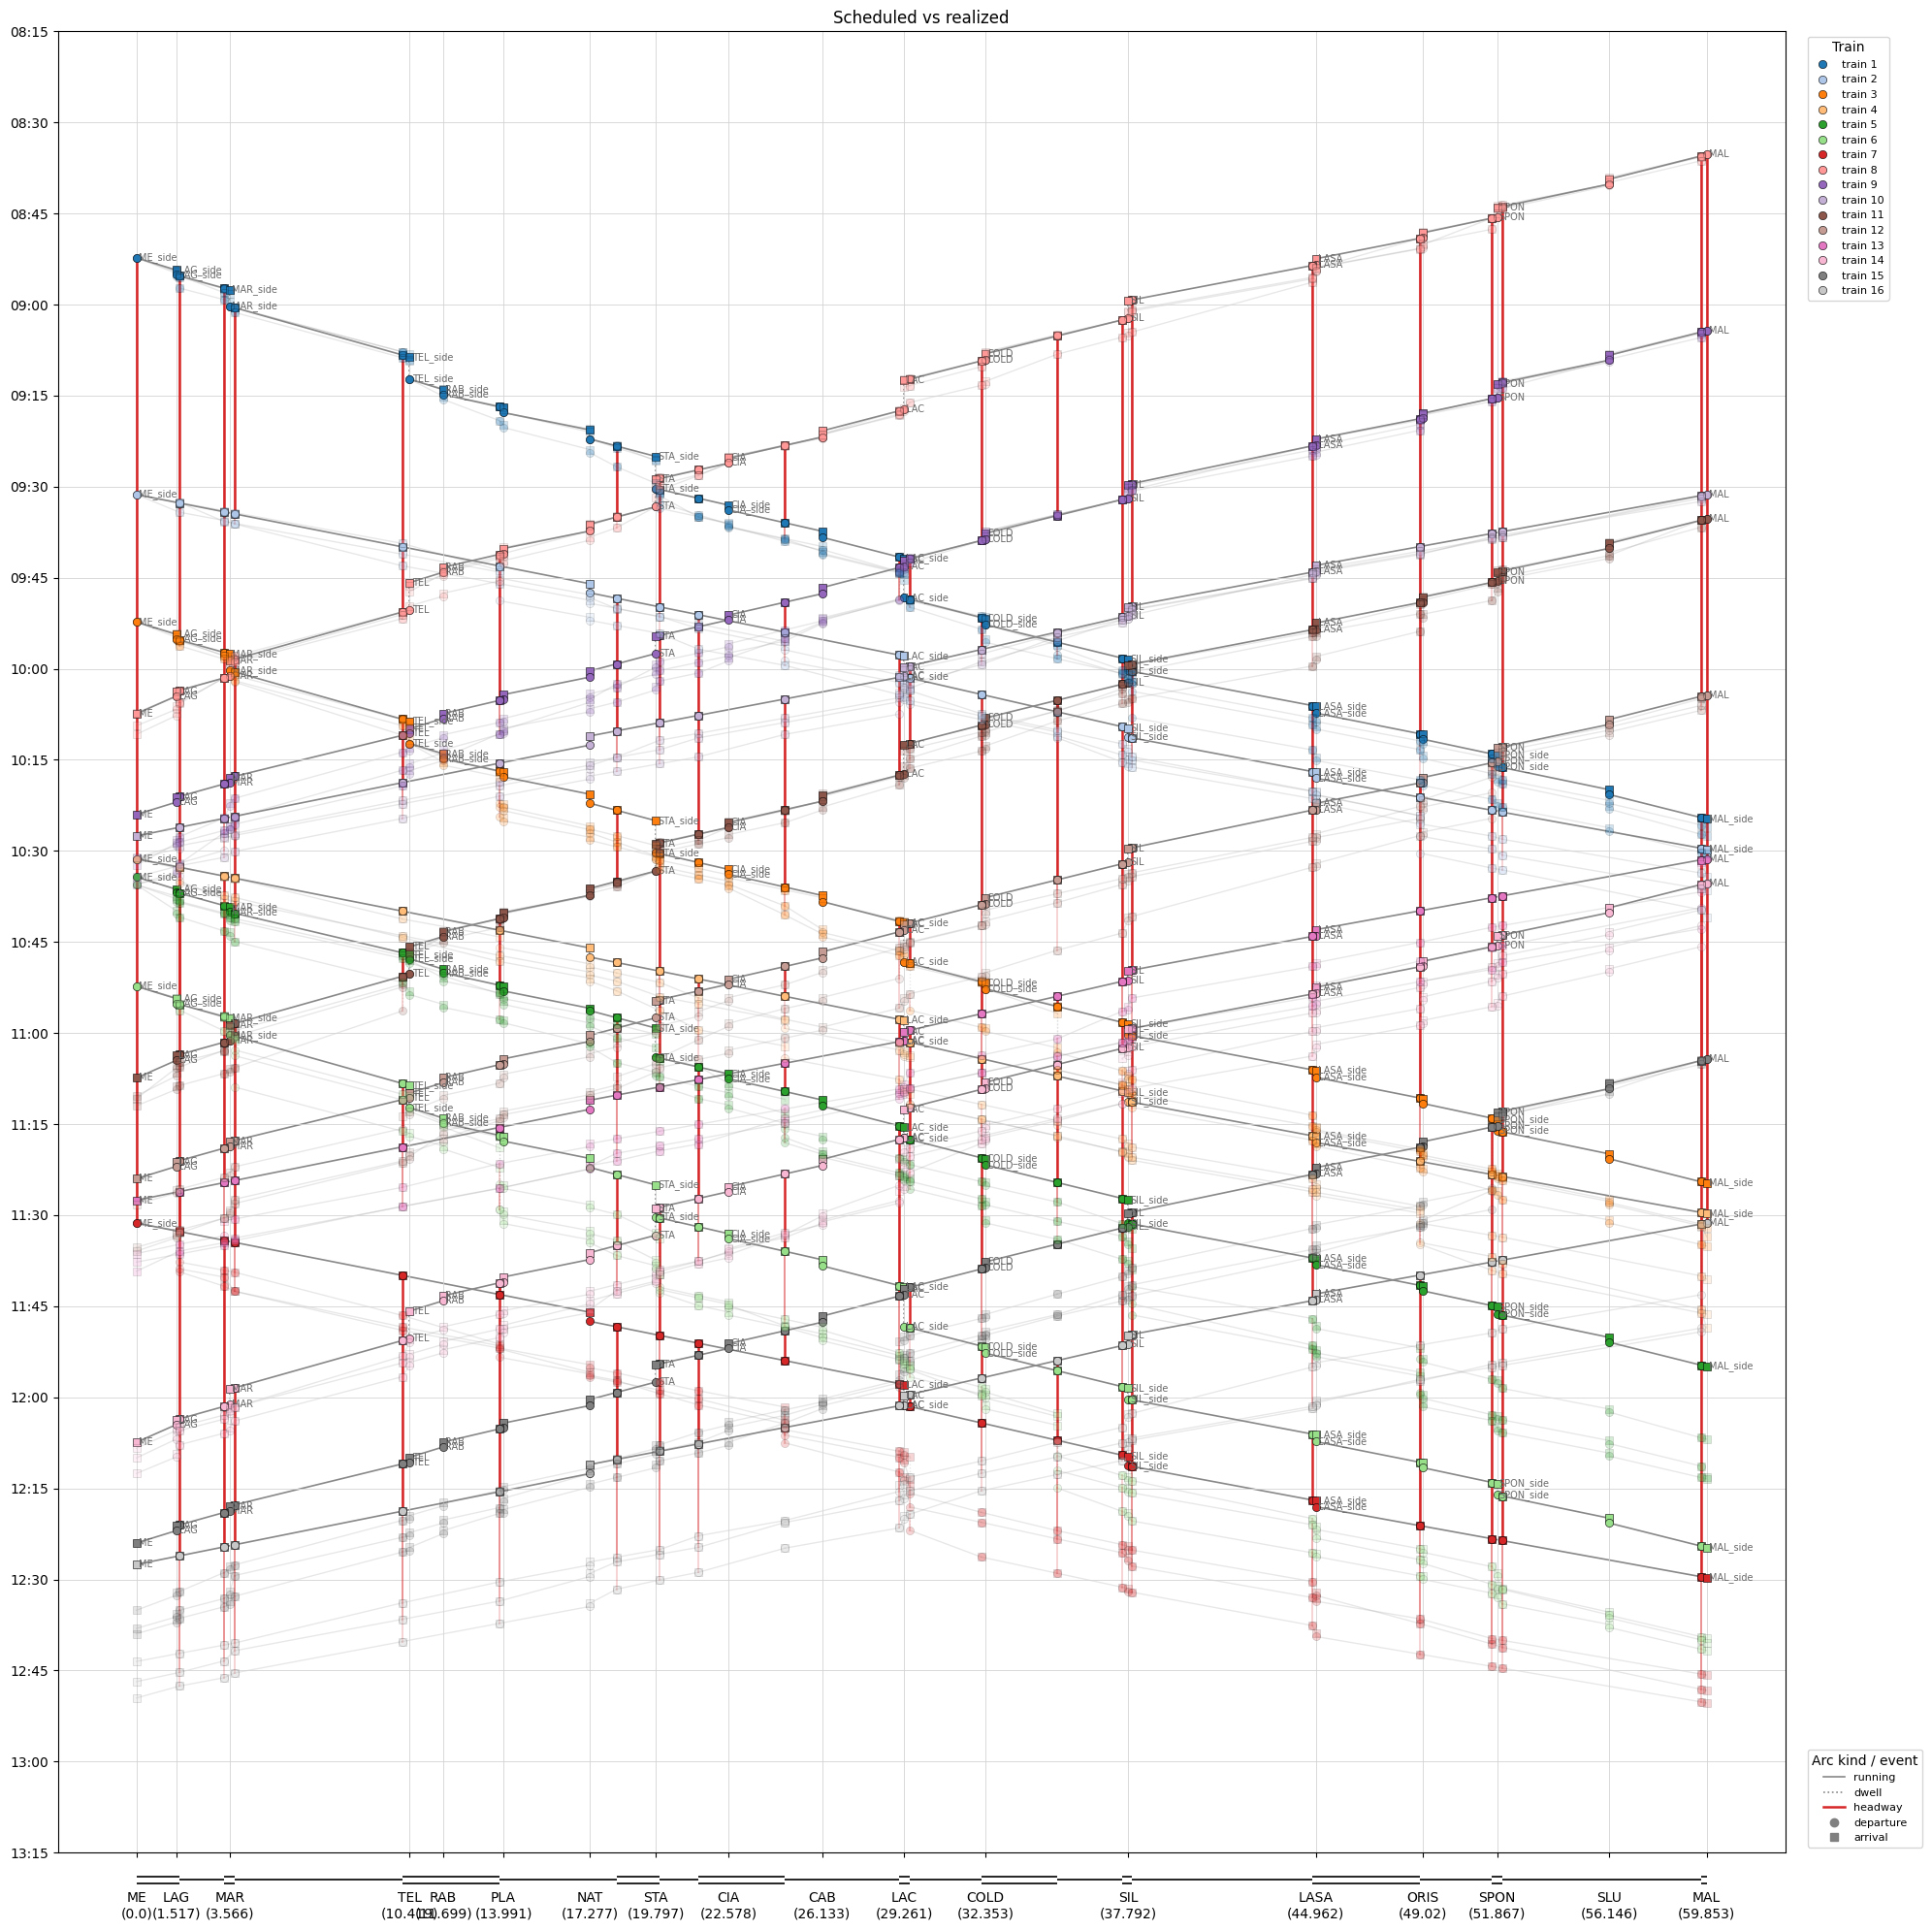

In [38]:
realized_graphs = []

for node_p, edge_p in zip(node_perturbations, edge_perturbations):

    G_realized = propagate2(
        G_scheduled,
        edge_perturbations=edge_p,
    )

    realized_graphs.append(G_realized)


fig, ax = plot_ean(G_scheduled,nodesDf,edgesDf,title="Scheduled vs realized")

for G_realized in realized_graphs:
    draw_ean(G_realized,nodesDf,ax,alpha=0.2,linewidth_scale=0.8,)

## Report

In [45]:
def compute_train_durations(G):
    """
    Returns
    -------
    dict
        {train_id: duration (timedelta)}
    """
    durations = {}
    trains = sorted({data["train"] for _, data in G.nodes(data=True) if "train" in data})

    for train in trains:
        events = [data for _, data in G.nodes(data=True) if data.get("train") == train]
        dep = min(e["time"] for e in events if e["event"] == "dep")
        arr = max(e["time"] for e in events if e["event"] == "arr")
        durations[train] = arr - dep
        
    return durations

In [46]:
def compare_to_schedule(G_scheduled, G_realized):
    scheduled = compute_train_durations(G_scheduled)
    realized = compute_train_durations(G_realized)
    report = {}
    for train in scheduled:
        report[train] = {"scheduled": scheduled[train], "realized": realized[train], "extra_time": realized[train] - scheduled[train]}
    return report

In [47]:
# Arrival delay at destination station
arrival_report = compare_to_schedule(G_scheduled, G_realized)

for i, (node_perturbation, edge_perturbation, G_realized) in enumerate(zip(node_perturbations, edge_perturbations, realized_graphs)):

    arrival_report = compare_to_schedule(G_scheduled, G_realized)

    # Initial departure delays per train
    departure_delay = defaultdict(float)

    for node, delay in node_perturbation.items():
        train = G_scheduled.nodes[node]["train"]
        departure_delay[train] += delay

    # Sum of imposed running-time extensions per train
    running_delay = defaultdict(float)

    for (u, v), delay in edge_perturbation.items():
        train = G_scheduled.nodes[u]["train"]
        running_delay[train] += delay

    total_dep = 0
    total_run = 0
    total_sec = 0

    print(f"\nScenario {i}")
    print("-" * 70)

    for train in sorted(arrival_report):

        dep = departure_delay[train]
        run = running_delay[train]
        sec = arrival_report[train]["extra_time"]

        total_dep += dep
        total_run += run
        total_sec += sec

        print(
            f"Train {train:>2}: "
            f"departure={dep:6.0f}s   "
            f"running={run:6.0f}s   "
            f"arrival delay={sec:6.0f}s"
        )

    n = len(arrival_report)

    print("\nTotals")
    print(f"  Initial departure delays : {total_dep:.0f} s")
    print(f"  Running-time extensions  : {total_run:.0f} s")
    print(f"  Arrival delays           : {total_sec:.0f} s")

    print("\nAverage per train")
    print(f"  Initial departure delays : {total_dep/n:.1f} s")
    print(f"  Running-time extensions  : {total_run/n:.1f} s")
    print(f"  Arrival delays           : {total_sec/n:.1f} s")


Scenario 0
----------------------------------------------------------------------
Train  1: departure=   337s   running=   802s   arrival delay=   165s
Train  2: departure=   175s   running=   424s   arrival delay=   410s
Train  3: departure=   390s   running=   432s   arrival delay=   439s
Train  4: departure=   413s   running=   778s   arrival delay=  1131s
Train  5: departure=    66s   running=   676s   arrival delay=  1015s
Train  6: departure=   144s   running=   848s   arrival delay=  1018s
Train  7: departure=   315s   running=   572s   arrival delay=  1236s
Train  8: departure=   262s   running=  1008s   arrival delay=   204s
Train  9: departure=   298s   running=   937s   arrival delay=   503s
Train 10: departure=   198s   running=   604s   arrival delay=   223s
Train 11: departure=   406s   running=  1055s   arrival delay=   177s
Train 12: departure=   393s   running=   710s   arrival delay=   254s
Train 13: departure=   308s   running=   548s   arrival delay=   612s
Train 1

# Manual Perturbation

## Propagation

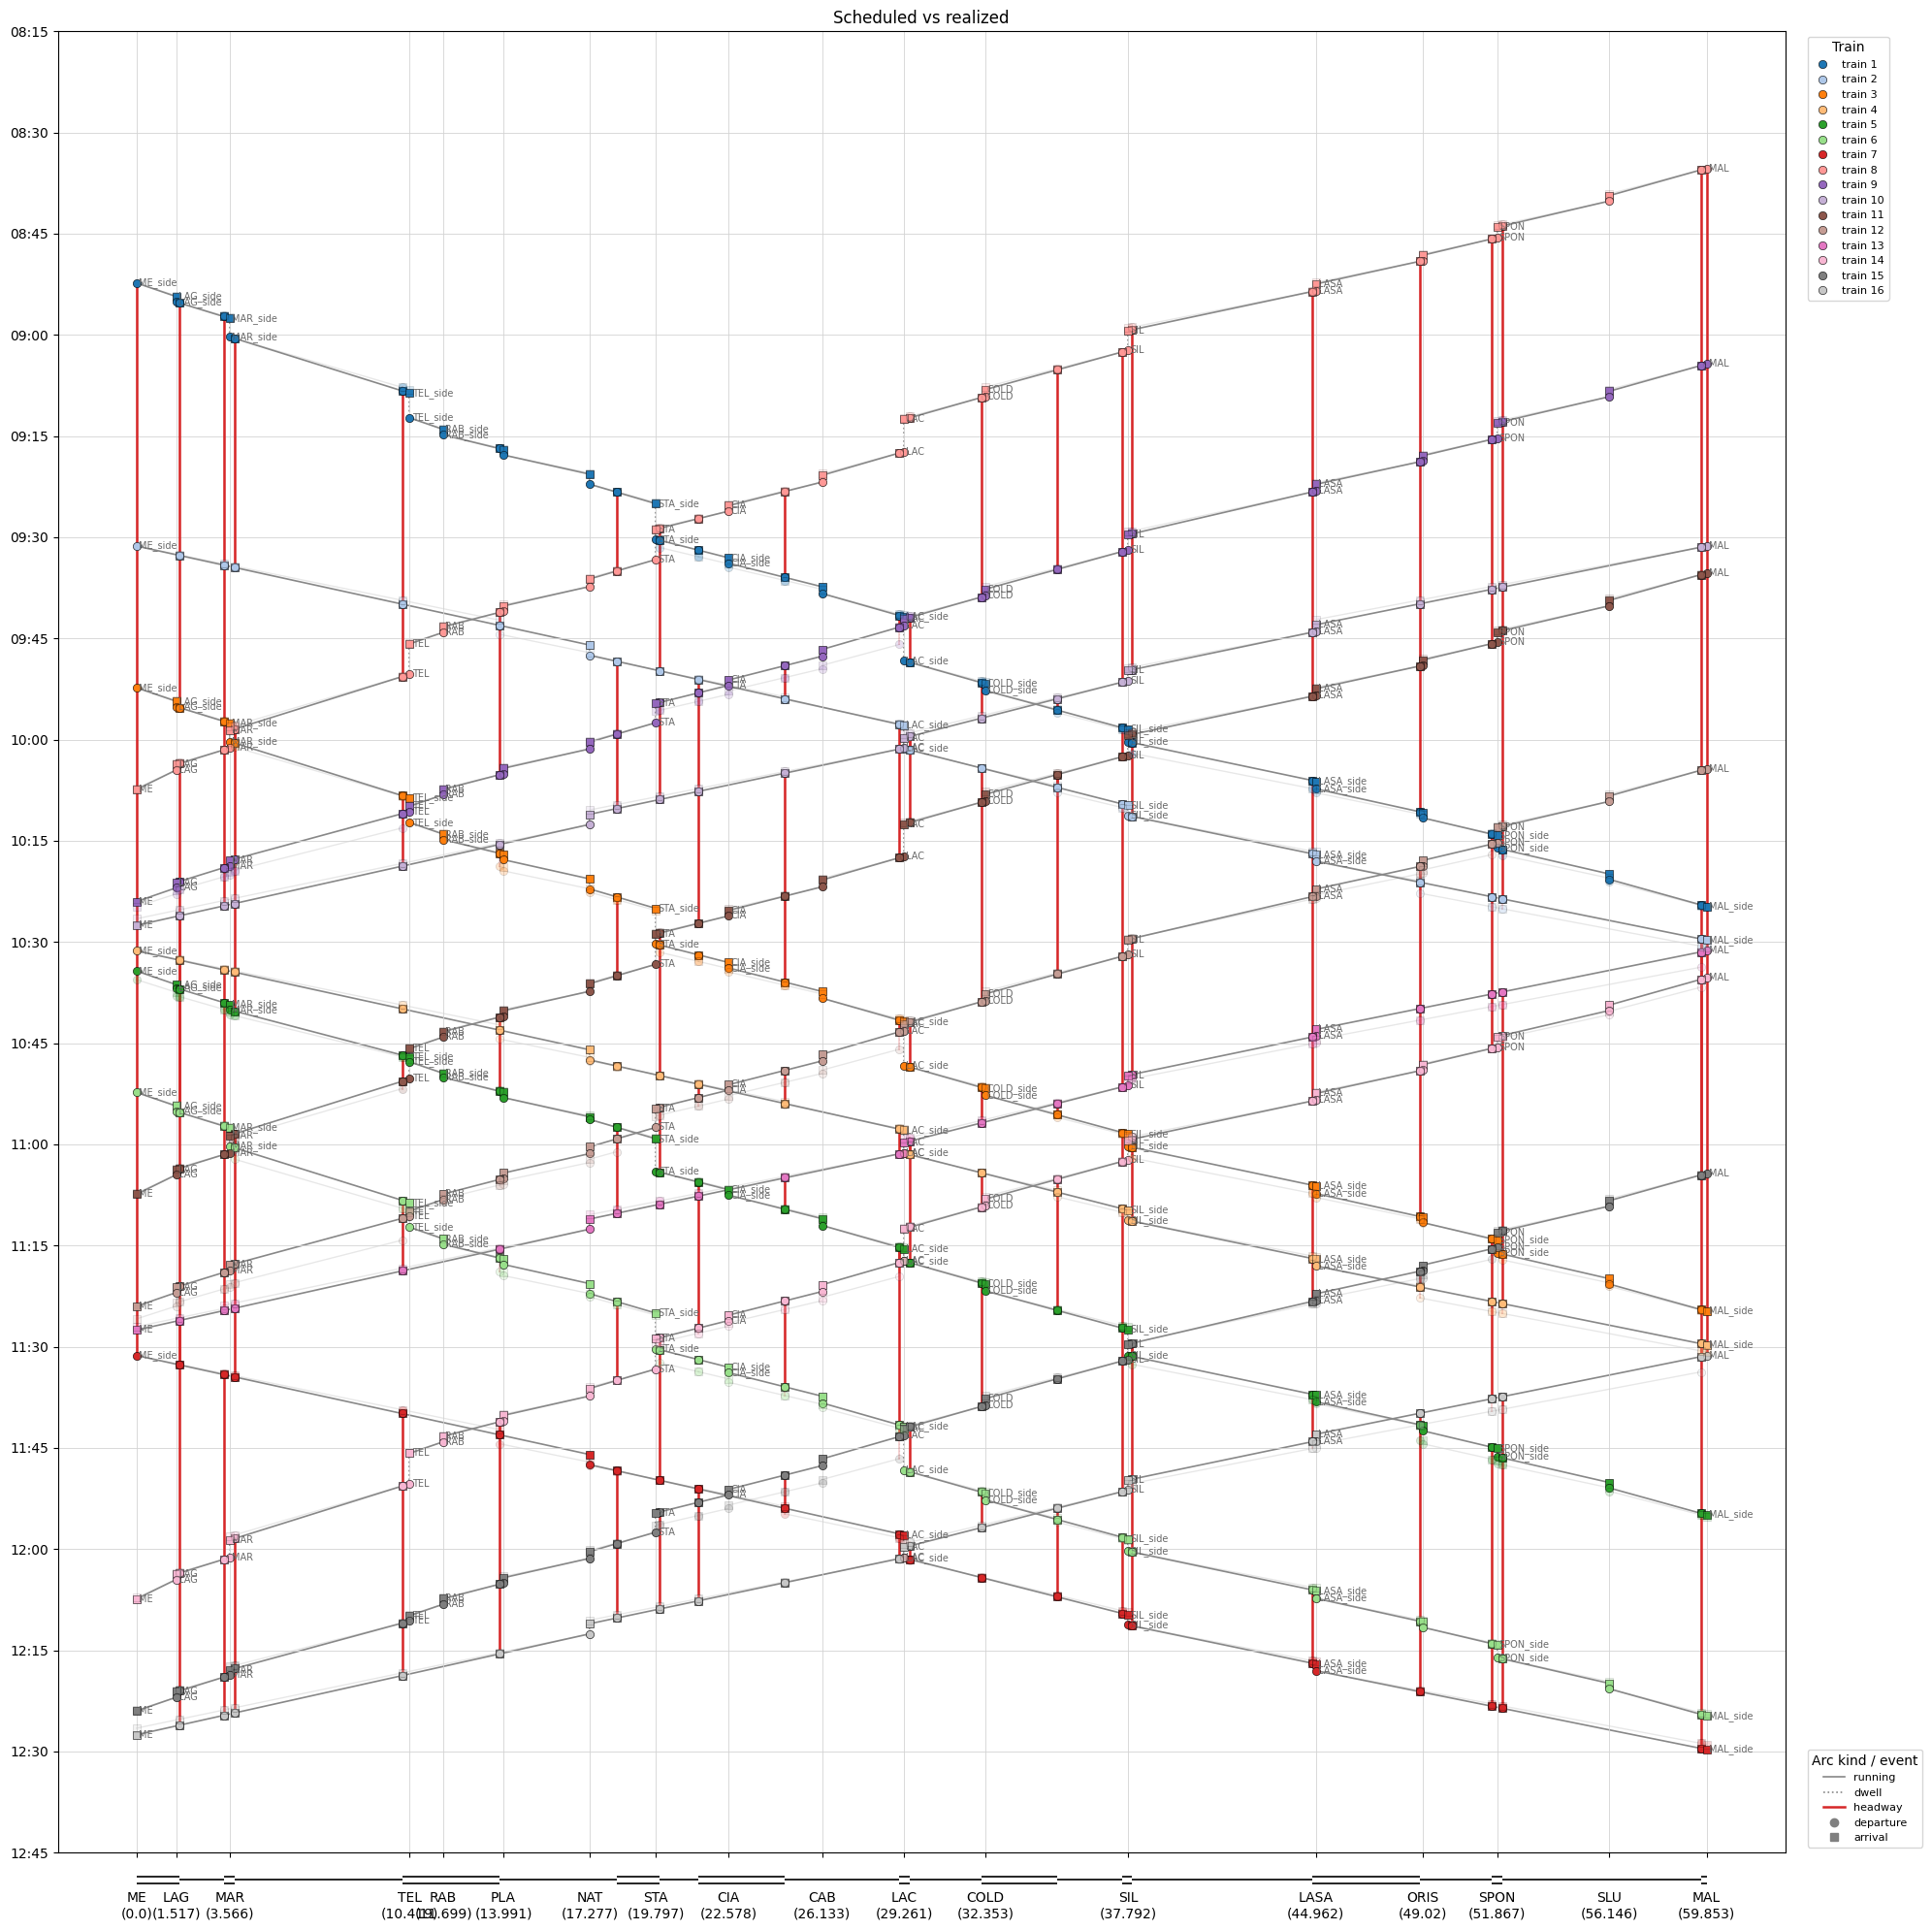

In [35]:
#inject delays manually
running_edges = [(u, v) for u, v, data in G_scheduled.edges(data=True) if data["kind"] == "running"]
edge = running_edges[0]  

#perturbations = [{},{edge: 60},{edge: 120},{edge: 300}]
perturbations = [{edge:0}]


realized_graphs = []

for p in perturbations:

    G_realized = propagate(G_scheduled, p)

    realized_graphs.append(G_realized)


fig, ax = plot_ean(G_scheduled, nodesDf, edgesDf, title="Scheduled vs realized")

for G_realized in realized_graphs:
    draw_ean(G_realized,nodesDf,ax,alpha=0.2,linewidth_scale=0.8,)

## Report

In [36]:
scheduled = compute_train_durations(G_scheduled)

for i, (perturbation, G_realized) in enumerate(zip(perturbations, realized_graphs)):
    realized = compute_train_durations(G_realized)
    primary = sum(perturbation.values()) if perturbation else 0
    print(f"\nPerturbation {i}  (primary delay = {primary:.0f} s)")
    print("-" * 45)
    secondary = 0
    for train in sorted(scheduled):
        extra = realized[train] - scheduled[train]
        # primary delay belongs to the perturbed train only
        propagated = extra - primary if train == 1 else extra
        secondary += max(0, propagated)
        print(
            f"Train {train:>2}: "
            f"scheduled={scheduled[train]:6.0f}s  "
            f"realized={realized[train]:6.0f}s  "
            f"Δ={extra:5.0f}s"
        )

    avg_pri = primary/len(realized)
    avg_sec = secondary/len(realized)
    
    print(f"\n Total primary delay   : {primary:.0f} s")
    print(f"Total secondary delay : {secondary:.0f} s")
    print(f"\n Average primary delay   : {avg_pri:.0f} s")
    print(f"Average secondary delay   : {avg_sec:.0f} s")


Perturbation 0  (primary delay = 0 s)
---------------------------------------------
Train  1: scheduled=  5546s  realized=  5550s  Δ=    4s
Train  2: scheduled=  3505s  realized=  3569s  Δ=   64s
Train  3: scheduled=  5546s  realized=  5550s  Δ=    4s
Train  4: scheduled=  3505s  realized=  3569s  Δ=   64s
Train  5: scheduled=  4838s  realized=  4775s  Δ=  -63s
Train  6: scheduled=  5546s  realized=  5530s  Δ=  -16s
Train  7: scheduled=  3505s  realized=  3459s  Δ=  -46s
Train  8: scheduled=  5526s  realized=  5515s  Δ=  -11s
Train  9: scheduled=  4782s  realized=  4828s  Δ=   46s
Train 10: scheduled=  3374s  realized=  3315s  Δ=  -59s
Train 11: scheduled=  5526s  realized=  5515s  Δ=  -11s
Train 12: scheduled=  4782s  realized=  4895s  Δ=  113s
Train 13: scheduled=  3374s  realized=  3344s  Δ=  -30s
Train 14: scheduled=  5526s  realized=  5515s  Δ=  -11s
Train 15: scheduled=  4782s  realized=  4774s  Δ=   -8s
Train 16: scheduled=  3374s  realized=  3315s  Δ=  -59s

 Total primary del